In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# 1. 시드 고정 및 데이터 개수 설정
np.random.seed(42)
n = 10000

# 2. 가상 데이터 생성 (모든 오타 완벽 수정)
gate_count = np.random.randint(100, 50000, n)
wire_length = np.random.randint(100, 50000, n)
fanout = np.random.randint(1, 20, n)
logic_depth = np.random.randint(5, 80, n)
frequency = np.random.randint(100e6, 2e9, n)
vdd = np.random.uniform(0.7, 1.2, n)          
toggle_rate = np.random.uniform(0.01, 0.5, n)    
temperature = np.random.randint(250, 400, n)

# 3. PPA 수식 계산
capacitance = (gate_count * 1e-15) + (fanout * 5e-15) + (wire_length * 1e-18)
dynamic_power = (toggle_rate * capacitance * (vdd ** 2) * frequency) * 1e3
leakage_power = (gate_count * vdd * np.exp((temperature - 300) / 80) * 5e-8) * 1e3
power = dynamic_power + leakage_power + np.random.normal(0, 0.02 * dynamic_power.std(), n)

delay = ((capacitance * vdd / 1e-3) * 1e9) + (logic_depth * 0.05) + ((temperature - 300) * 0.08) + np.random.normal(0, 0.2, n)
area = (gate_count * 0.8) + (wire_length * 0.12) + (fanout * 15) + np.random.normal(0, 400, n)

power = np.clip(power, 0.001, None)
delay = np.clip(delay, 0.01, None)
area = np.clip(area, 0.001, None)

# 4. 데이터프레임 생성 및 CSV 저장
df = pd.DataFrame({
    'gate_count': gate_count,
    'wire_length_um': wire_length,
    'fanout': fanout,
    'logic_depth': logic_depth,
    'frequency_hz': frequency,
    'vdd_v': vdd,
    'toggle_rate': toggle_rate,
    'temperature_k': temperature,
    'power_mw': power,
    'delay_ns': delay,
    'area_um2': area
})
df.to_csv('KUPY2.csv', index=False)
print("👉 1. KUPY2.csv 데이터 생성 완료!")

# 5. 데이터 분할 및 스케일링 전처리
X = df[['gate_count', 'wire_length_um', 'fanout', 'logic_depth', 'frequency_hz', 'vdd_v', 'toggle_rate', 'temperature_k']]
y = df[['power_mw', 'delay_ns', 'area_um2']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

# 6. 파이토치 텐서 변환
X_train_tensor = torch.FloatTensor(X_train_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_train_tensor = torch.FloatTensor(y_train_scaled)
y_test_tensor = torch.FloatTensor(y_test_scaled)

# 7. 딥러닝 모델 정의 (app.py와 구조 완벽 통일)
class PPANet(nn.Module):
    def __init__(self):
        super(PPANet, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(8, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 3)
        )

    def forward(self, x):
        return self.model(x)

model = PPANet()

# 8. 모델 학습 진행
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("머신러닝 모델 학습 시작...")
epochs = 300
for epoch in range(epochs):
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}")

# 9. 성능 검증 (R² Score)
model.eval()
with torch.no_grad():
    pred_scaled = model(X_test_tensor).numpy()
pred = y_scaler.inverse_transform(pred_scaled)
print(f"모델 검증 완료! Test R2 Score: {r2_score(y_test, pred):.4f}")

# 10. 배포용 파일 저장 (가장 중요)
torch.save(model.state_dict(), "ppa_model.pth")
joblib.dump(x_scaler, "x_scaler.pkl")
joblib.dump(y_scaler, "y_scaler.pkl")
print("👉 2. ppa_model.pth, x_scaler.pkl, y_scaler.pkl 파일 저장 완료!")

In [2]:
!pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)


In [3]:
import xgboost as xgb

In [4]:
#시드 고정 및 데이터 ㄱ메수 설정
np.random.seed(42)
n=10000

In [5]:
gate_count = np.random.randint(100, 50000, n)
wire_length = np.random.randint(100, 50000, n)
fanout = np.random.randint(1, 20, n)
logic_depth = np.random.randint(5, 80, n)

frequency = np.random.randint(100e6, 2e9, n)
vdd = np.random.uniform(0.7, 1.2, n)
toggle_gate = np.random.uniform(0.01, 0.5, n)

temperature =  np.random.randint(250, 400, n)

In [6]:
capacitance = (
    gate_count * 1e-15 +
    fanout * 5e-15 +
    wire_length * 1e-18
)
k = 1.3e-23
q = 1.6022e-19

thermal_voltage = (k * temperature )/ q

In [7]:
dynamic_power = (
    toggle_gate  * 
    capacitance *
    (vdd ** 2) *
    frequency 
) * 1e3

leakage_power = (
    gate_count *
    vdd *
    np.exp((temperature -300)/80)
    * 5e-8
) * 1e3

power = dynamic_power + leakage_power + np.random.normal(
    0, 0.02 * dynamic_power.std(), n
)

delay = (
    (capacitance * vdd / 1e-3) * 1e9
    + logic_depth * 0.05
    +(temperature-300)*0.08
    +np.random.normal(0,0.2,n)
)

area = (
    gate_count * 0.8
    + wire_length * 0.12
    + fanout *15
    + np.random.normal(0,400,n)
)

power = np.clip(power, 0.001, None)
delay = np.clip(delay, 0.01, None)
area = np.clip(area, 0.001, None)



In [8]:
df = pd.DataFrame({
    'gate_count': gate_count,
    'wire_length_um': wire_length,
    'fanout': fanout,
    'logic_depth': logic_depth,
    'frequency_hz': frequency,
    'vdd_v': vdd,
    'toggle_gate': toggle_gate,
    'temperature_k': temperature,

    'power_mw': power,
    'delay_ns': delay,
    'area_um2': area
})

In [9]:
df.to_csv('KUPY2.csv', index = False)
print("csv 저장완료")

csv 저장완료


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gate_count      10000 non-null  int32  
 1   wire_length_um  10000 non-null  int32  
 2   fanout          10000 non-null  int32  
 3   logic_depth     10000 non-null  int32  
 4   frequency_hz    10000 non-null  int32  
 5   vdd_v           10000 non-null  float64
 6   toggle_gate     10000 non-null  float64
 7   temperature_k   10000 non-null  int32  
 8   power_mw        10000 non-null  float64
 9   delay_ns        10000 non-null  float64
 10  area_um2        10000 non-null  float64
dtypes: float64(5), int32(6)
memory usage: 625.1 KB


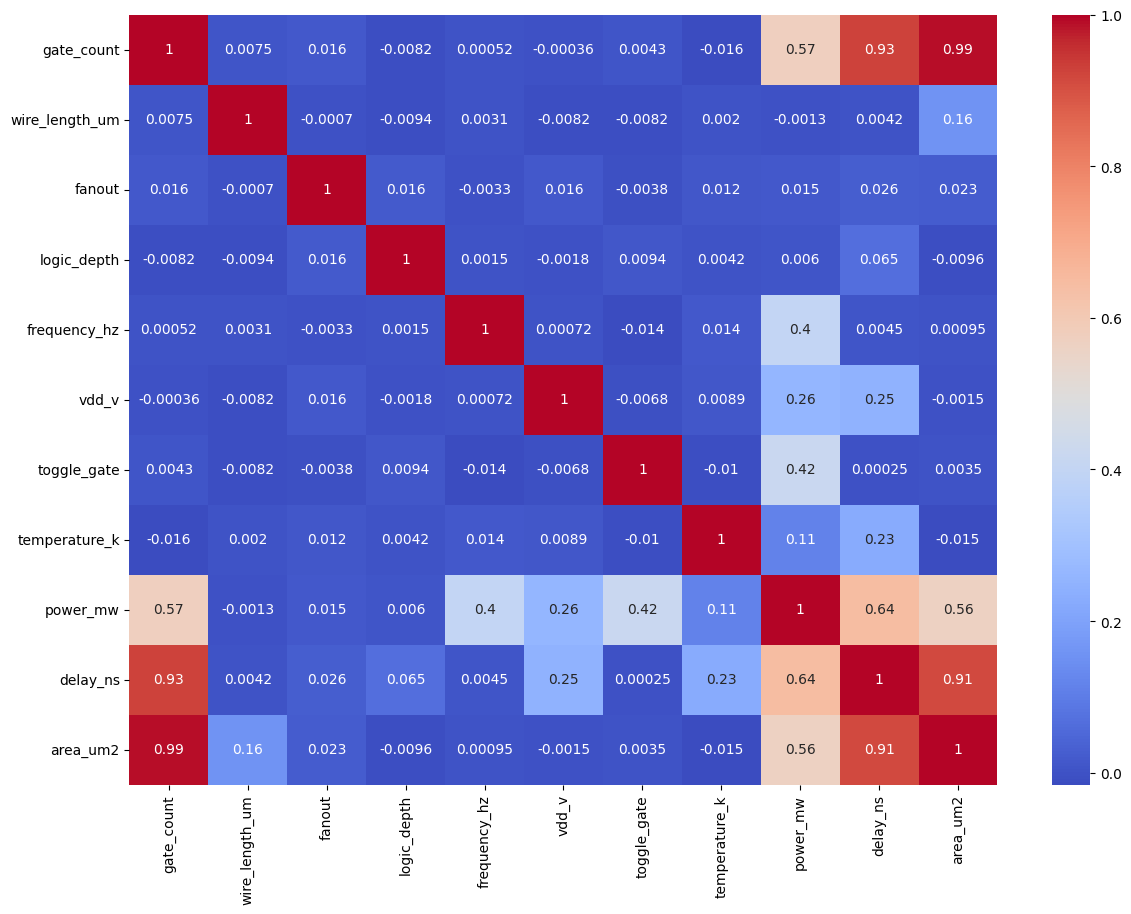

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot =True, cmap='coolwarm')
plt.show()

In [12]:
X = df[[
    'gate_count', 'wire_length_um', 'fanout', 'logic_depth', 
    'frequency_hz', 'vdd_v', 'toggle_gate', 'temperature_k'
]]

y = df[[
    'power_mw', 'delay_ns', 'area_um2'
]]

    
    

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size = 0.2,
    random_state = 42)
    
    

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [15]:
model = RandomForestRegressor(
    n_estimators = 100,
    random_state=42)
model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [16]:
pred = model.predict(X_test)
from sklearn.metrics import mean_absolute_error
print(mean_absolute_error(y_test, pred))


125.88191752566281


In [17]:
targets = [ 'power_mw', 'delay','area_um2']

for i , target in enumerate(targets):
    mae = mean_absolute_error(y_test.iloc[:,i],pred[:,i])
    print(f"{target}: {mae}")
    

power_mw: 3.596086226023786
delay: 3.5661186206350064
area_um2: 370.4835477303291


In [18]:
from sklearn.metrics import r2_score
print(r2_score(y_test,pred))


0.8118022745057035


In [19]:
import torch
import torch.nn as nn
import torch.optim as optim


In [20]:
from sklearn.preprocessing import StandardScaler  

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train) 
X_test_scaled = x_scaler.transform(X_test)

y_train_scaled = y_scaler.fit_transform(y_train) 

y_test_scaled = y_scaler.transform(y_test)


In [21]:

X_train_tensor = torch.FloatTensor(X_train_scaled)

X_test_tensor = torch.FloatTensor(X_test_scaled) 


y_train_tensor = torch.FloatTensor(y_train_scaled)

y_test_tensor = torch.FloatTensor(y_test_scaled)

In [22]:
class PPANet(nn.Module):
    def __init__(self):
        # 여기서부터 들여쓰기(Tab)가 한 번 더 들어가야 합니다!
        super(PPANet, self).__init__()
        
        self.model = nn.Sequential(
            nn.Linear(8, 64),
            nn.ReLU(),
            
            nn.Linear(64, 128),
            nn.ReLU(),
            
            nn.Linear(128, 64),
            nn.ReLU(),
            
            nn.Linear(64, 3),
            
        )
        
    def forward(self, x):
        return self.model(x)
    

In [23]:
# 1. weights_only=False 옵션을 추가하여 보안 차단을 해제합니다.
checkpoint = torch.load("ppa_model.pth", map_location="cpu", weights_only=False)

# 2. keys()를 빼고, 불러온 모델 전체 구조를 그대로 출력해 봅니다.
print(checkpoint)

OrderedDict({'model.0.weight': tensor([[ 6.2323e-02, -2.0557e-01, -2.5678e-01, -2.8946e-01,  2.3740e-01,
          3.4493e-01, -2.6358e-01, -2.5876e-01],
        [ 3.6809e-01,  2.7391e-01,  1.0164e-01, -1.6675e-01, -1.5836e-01,
          2.1513e-01, -2.5405e-01, -1.6799e-01],
        [-3.2124e-01, -2.0684e-01, -4.8146e-02,  1.0909e-03, -2.6882e-01,
          2.5577e-01,  2.7486e-01, -4.6290e-02],
        [-2.9212e-01, -1.9597e-02, -3.2211e-01, -2.3432e-01, -4.8276e-02,
          2.9266e-01,  2.2084e-02,  2.7203e-01],
        [-3.6431e-01,  2.3152e-02, -1.7003e-01, -1.9878e-01, -2.2590e-01,
          3.1828e-01, -2.3207e-01, -1.1920e-01],
        [-2.0806e-01,  2.0409e-02, -4.9843e-02, -2.4326e-01,  2.1254e-01,
          3.2119e-02,  5.9387e-02,  1.3120e-01],
        [-2.9497e-01, -2.8678e-01,  2.5132e-01, -1.1754e-01,  3.3645e-01,
         -3.2532e-01, -6.8213e-02, -1.0196e-02],
        [ 3.5541e-01, -2.2656e-01,  1.8314e-01,  2.2703e-01, -3.3424e-04,
          2.0889e-01, -2.1095e-01,

In [24]:
model = PPANet()

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr = 0.001
     )


In [25]:
epochs = 300
for epoch in range(epochs):
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    optimizer.zero_grad()

    loss.backward()
    optimizer.step()
    if (epoch+1) %50 == 0:
        print(f"Epoch [ {epoch +1}/ {epochs}], Loss: {loss.item():4f}")

        

Epoch [ 50/ 300], Loss: 0.057355
Epoch [ 100/ 300], Loss: 0.013351
Epoch [ 150/ 300], Loss: 0.007841
Epoch [ 200/ 300], Loss: 0.005903
Epoch [ 250/ 300], Loss: 0.004895
Epoch [ 300/ 300], Loss: 0.004205


In [26]:

xgb_model = xgb.XGBRegressor(
    n_estimators=500, 
    learning_rate=0.05, 
    max_depth=6,       
    random_state=42
)

xgb_model.fit(X_train_scaled, y_train_scaled)

print("XGBoost 학습 완료!")

XGBoost 학습 완료!


In [27]:
# 수정 전 (PyTorch)
# with torch.no_grad():
#     pred_scaled = model(X_test_tensor).numpy()

# 수정 후 (XGBoost)
pred_scaled = xgb_model.predict(X_test_scaled)

# 이후 역스케일링 과정은 동일합니다
pred = y_scaler.inverse_transform(pred_scaled)

In [28]:
with torch.no_grad():
    pred_scaled = model(X_test_tensor).numpy()

pred = y_scaler.inverse_transform(pred_scaled)


In [29]:
print("R^2:", r2_score(y_test, pred))

targets = ['power_mw', 'delay_ns', 'area_um2']  # ms -> mw 로 단위 통일!
for i, target in enumerate(targets):            # targer -> target 오타 수정!
    
    # 1. 띄어쓰기 대신 언더바(_) 사용
    # 2. i;oc -> iloc 오타 수정 및 숫자 1을 변수 i로 변경
    mae = mean_absolute_error(y_test.iloc[:, i], pred[:, i])
    
    print(f"{target} : {mae}")

R^2: 0.9952085018157959
power_mw : 0.4916526941398106
delay_ns : 0.61568244531907
area_um2 : 556.6476530131581


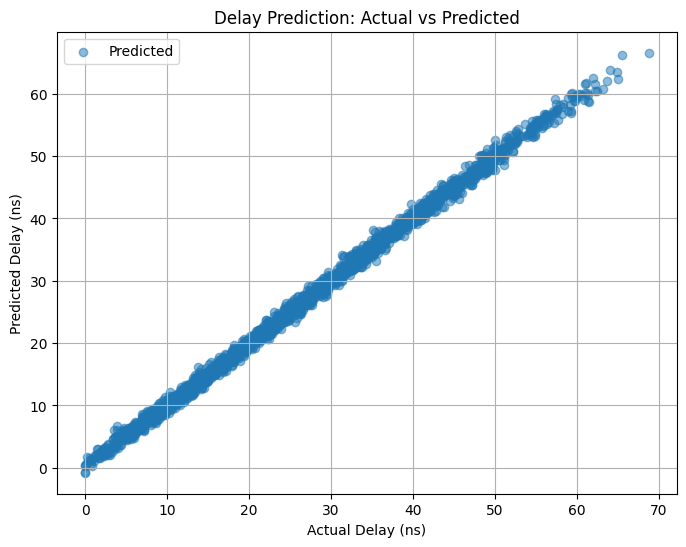

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# 1. 산점도: 실제 Delay vs 예측 Delay (인덱스 1번 확인)
# 만약 pred가 numpy 배열이라면 delay는 보통 1번 인덱스입니다.
plt.scatter(y_test['delay_ns'], pred[:, 1], alpha=0.5, label='Predicted')

# 2. 기준선 (일차함수 y=x): 모델이 완벽할 때 점들이 위치해야 하는 선
# x축과 y축의 범위를 실제 delay_ns의 최소/최대값으로 맞춥니다.
min_val = y_test['delay_ns'].min()
max_val = y_test['delay_ns'].max()


# 3. 그래프 설정 (tittle -> title 오타 수정)
plt.xlabel("Actual Delay (ns)")
plt.ylabel("Predicted Delay (ns)")
plt.title("Delay Prediction: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()


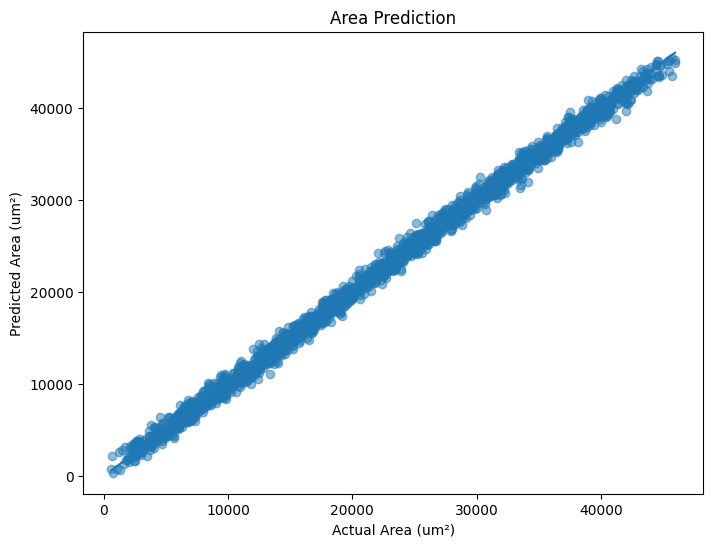

In [31]:
plt.figure(figsize=(8,6))
plt.scatter(y_test['area_um2'], pred[:,2], alpha=0.5)

plt.xlabel("Actual Area (um²)")
plt.ylabel("Predicted Area (um²)")
plt.title("Area Prediction")

plt.plot(
    [y_test['area_um2'].min(), y_test['area_um2'].max()],
    [y_test['area_um2'].min(), y_test['area_um2'].max()]
)

plt.show()

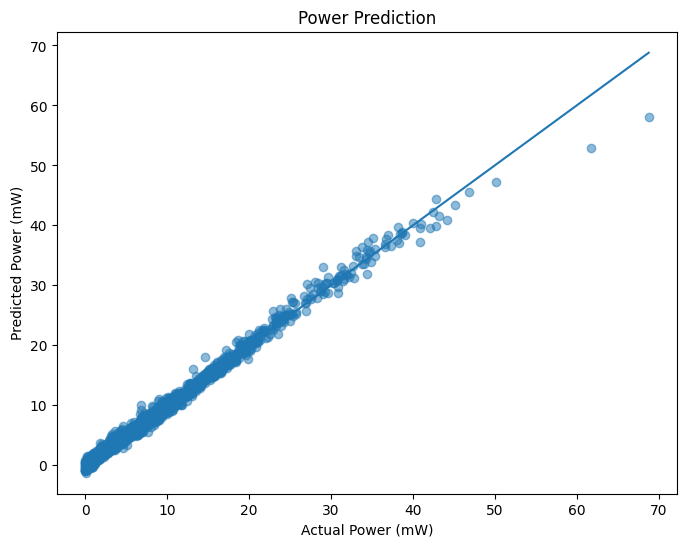

In [32]:
import matplotlib.pyplot as plt
# 실제값 vs 예측값 산점도(Scatter plot) 시각화 (Power 기준)
# 데이터가 대각선에 몰려 있을수록 예측이 정확하다는 의미
plt.figure(figsize=(8,6))
plt.scatter(y_test['power_mw'], pred[:,0], alpha=0.5)
plt.xlabel("Actual Power (mW)")
plt.ylabel("Predicted Power (mW)")
plt.title("Power Prediction")

plt.plot(
    [y_test['power_mw'].min(), y_test['power_mw'].max()],
    [y_test['power_mw'].min(), y_test['power_mw'].max()]
)

In [33]:
with torch.no_grad():
    train_pred_scaled = model(X_train_tensor).numpy()
train_pred = y_scaler.inverse_transform(train_pred_scaled)

print("Train R^2:", r2_score(y_train, train_pred))
print("Test R^2:", r2_score(y_test,pred))


Train R^2: 0.9958062171936035
Test R^2: 0.9952085018157959


In [34]:
torch.save(model.state_dict(), "ppa_model.pth")


In [35]:
import joblib
joblib.dump(x_scaler, "x_scaler.pkl")
joblib.dump(y_scaler, "y_scaler.pkl")


['y_scaler.pkl']

In [36]:
import os
print(os.listdir())


['.anaconda', '.conda', '.condarc', '.continuum', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.keras', '.LdVirtualBox', '.matplotlib', '.ms-ad', '.spss', '26.0503.ipynb', '3D Objects', 'anaconda3', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'Documents', 'Downloads', 'Favorites', 'IntelGraphicsProfiles', 'KCase.log', 'KUPY2.csv', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{e9e0a88f-eb5a-11ef-9de8-baeda40dc92d}.TM.blf', 'NTUSER.DAT{e9e0a88f-eb5a-11ef-9de8-baeda40dc92d}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{e9e0a88f-eb5a-11ef-9de8-baeda40dc92d}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'ppa_model.pth', 'PrintHood', 'PyCharmMiscProject', 'PyCharmMiscProject.iml', 'Recent', 'Saved Games', 'Searches', 'SendTo', 'source', 'Templates', 'tk_modeling', 'tracker.prefs', 'Untitled.ipynb', 'Videos', 'x_scaler.pkl', 'y_scaler.pkl', '광공학', '새 폴더